In [1]:
import os
import math
import random
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

VRAM_FRACTION = 1.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.cuda.set_per_process_memory_fraction(VRAM_FRACTION, device=0)
    print(f'Using device: {device}  |  VRAM cap: {VRAM_FRACTION*100:.0f}%')
else:
    print('Using device: cpu')

DATA_ROOT  = os.path.join(os.getcwd(), 'data')
MODEL_ROOT = os.path.join(os.getcwd(), 'models')
os.makedirs(MODEL_ROOT, exist_ok=True)


Using device: cuda  |  VRAM cap: 100%


In [2]:
from helper_functions.utils import PersonReIDDataset

MARKET_ROOT = os.path.join(DATA_ROOT, 'Market-1501-v15.09.15')

dataset_train   = PersonReIDDataset(os.path.join(MARKET_ROOT, 'bounding_box_train'), min_seq_len=1)
dataset_query   = PersonReIDDataset(os.path.join(MARKET_ROOT, 'query'),              min_seq_len=1)
dataset_gallery = PersonReIDDataset(os.path.join(MARKET_ROOT, 'bounding_box_test'),  min_seq_len=1,
                                    keep_distractors=True)

all_seqs_train   = [s for cams in dataset_train.sequences_by_person.values()
                      for seqs in cams.values() for s in seqs]
all_seqs_query   = [s for cams in dataset_query.sequences_by_person.values()
                      for seqs in cams.values() for s in seqs]
all_seqs_gallery = [s for cams in dataset_gallery.sequences_by_person.values()
                      for seqs in cams.values() for s in seqs]

print(f'Train identities  : {len(dataset_train.sequences_by_person)}')
print(f'Train sequences   : {len(all_seqs_train)}')
print(f'Query sequences   : {len(all_seqs_query)}')
print(f'Gallery sequences : {len(all_seqs_gallery)}  (incl. -1 distractors and 0000 background)')


Train identities  : 751
Train sequences   : 7251
Query sequences   : 3368
Gallery sequences : 11783  (incl. -1 distractors and 0000 background)


In [3]:
import numpy as np

lens = [len(s) for s in all_seqs_train]
print(f'Train seq lengths -- mean: {np.mean(lens):.1f}  median: {np.median(lens):.0f}  '
      f'p95: {np.percentile(lens,95):.0f}  p99: {np.percentile(lens,99):.0f}  max: {max(lens)}')


Train seq lengths -- mean: 1.8  median: 1  p95: 4  p99: 6  max: 17


In [4]:
import torchvision.transforms as T
from torch.utils.data import Sampler

MAX_SEQ_LEN = 8
P, K = 12, 4

train_transform = T.Compose([
    T.Resize((256, 128)),
    T.RandomHorizontalFlip(),
    T.Pad(10),
    T.RandomCrop((256, 128)),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    T.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3)),
])

test_transform = T.Compose([
    T.Resize((256, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class SequenceLabelDataset(Dataset):
    def __init__(self, sequences_by_person, transform, max_seq_len):
        self.transform          = transform
        self.max_seq_len        = max_seq_len
        self.samples            = []
        self.pid_to_indices     = {}
        self.pid_cam_to_indices = {}

        for pid, cam_data in sequences_by_person.items():
            for cam, seqs in cam_data.items():
                for seq in seqs:
                    i = len(self.samples)
                    self.samples.append((seq, pid))
                    self.pid_to_indices.setdefault(pid, []).append(i)
                    self.pid_cam_to_indices.setdefault(pid, {}).setdefault(cam, []).append(i)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, pid = self.samples[idx]
        paths  = [p.image_path for p in seq[:self.max_seq_len]]
        frames = [self._load(p) for p in paths]
        return torch.stack(frames), len(frames), pid

    def _load(self, path):
        return self.transform(Image.open(path).convert('RGB'))


class PKSampler(Sampler):
    def __init__(self, pid_to_indices, pid_cam_to_indices, P=12, K=4):
        self.pid_to_indices     = pid_to_indices
        self.pid_cam_to_indices = pid_cam_to_indices
        self.P = P
        self.K = K
        self.pids = [pid for pid, idxs in pid_to_indices.items() if len(idxs) >= 2]

    def _sample_cross_camera(self, pid):
        cam_data = self.pid_cam_to_indices[pid]
        cameras  = list(cam_data.keys())
        if len(cameras) == 1:
            return random.choices(self.pid_to_indices[pid], k=self.K)
        random.shuffle(cameras)
        cam_cycle = cameras * (self.K // len(cameras) + 1)
        return [random.choice(cam_data[cam]) for cam in cam_cycle[:self.K]]

    def __iter__(self):
        pids = self.pids.copy()
        random.shuffle(pids)
        for i in range(0, len(pids) - self.P + 1, self.P):
            batch = []
            for pid in pids[i : i + self.P]:
                batch.extend(self._sample_cross_camera(pid))
            yield batch

    def __len__(self):
        return len(self.pids) // self.P


def sequence_label_collate(batch):
    imgs_list, lengths, pids = zip(*batch)
    max_t = max(lengths)
    C, H, W = imgs_list[0].shape[1:]
    padded = torch.zeros(len(imgs_list), max_t, C, H, W)
    for i, (imgs, t) in enumerate(zip(imgs_list, lengths)):
        padded[i, :t] = imgs
    return padded, torch.tensor(lengths, dtype=torch.long), torch.tensor(pids, dtype=torch.long)


In [5]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import gc
import re

_CAM_RE = re.compile(r"c(\d+)")

def _cam_int(cam_str):
    m = _CAM_RE.match(cam_str)
    return int(m.group(1)) if m else -1


def encode_sequences(sequences, model, transform, device,
                      max_seq_len=None, batch_size=32, flip_tta=False):
    model.eval()

    def seq_len(seq):
        s = seq if max_seq_len is None else seq[:max_seq_len]
        return len(s)

    sequences = sorted(sequences, key=seq_len)
    all_embs, all_pids, all_cams = [], [], []

    def load_seq(seq, flipped=False):
        frames_to_use = seq if max_seq_len is None else seq[:max_seq_len]
        frames = []
        for p in frames_to_use:
            img = Image.open(p.image_path).convert('RGB')
            if flipped:
                img = img.transpose(Image.FLIP_LEFT_RIGHT)
            frames.append(transform(img))
        return torch.stack(frames), len(frames), seq[0].person_id, _cam_int(seq[0].camera_id)

    def run_batch(batch_seqs, flipped=False):
        results = [load_seq(s, flipped) for s in batch_seqs]
        imgs_list, lengths, pids, cams = zip(*results)
        max_t = max(lengths)
        C, H, W = imgs_list[0].shape[1:]
        padded = torch.zeros(len(imgs_list), max_t, C, H, W)
        for i, (imgs, t) in enumerate(zip(imgs_list, lengths)):
            padded[i, :t] = imgs
        lengths_t = torch.tensor(lengths, dtype=torch.long)
        with torch.amp.autocast('cuda'):
            embs = model(padded.to(device), lengths_t)
        return embs.cpu().float(), pids, cams

    with torch.no_grad():
        for start in tqdm(range(0, len(sequences), batch_size), desc='Encoding'):
            batch_seqs = sequences[start : start + batch_size]
            embs, pids, cams = run_batch(batch_seqs)
            if flip_tta:
                embs_flip, _, _ = run_batch(batch_seqs, flipped=True)
                import torch.nn.functional as F
                embs = F.normalize((embs + embs_flip) / 2, dim=1)
            all_embs.append(embs.numpy())
            all_pids.extend(pids)
            all_cams.extend(cams)

    return (np.concatenate(all_embs, axis=0),
            np.array(all_pids),
            np.array(all_cams))


def _score_with_junk(sorted_idx, q_pids, q_cams, g_pids, g_cams, max_rank=20):
    cmc = np.zeros(max_rank)
    aps = []
    valid = 0
    for i in range(len(q_pids)):
        order = sorted_idx[i]
        g_pid_i = g_pids[order]
        g_cam_i = g_cams[order]

        junk = (g_pid_i == 0) | (g_pid_i == -1) | \
               ((g_pid_i == q_pids[i]) & (g_cam_i == q_cams[i]))
        keep = ~junk
        g_pid_i = g_pid_i[keep]

        match = g_pid_i == q_pids[i]
        if match.sum() == 0:
            continue
        valid += 1

        for r in range(max_rank):
            if match[:r + 1].any():
                cmc[r:] += 1
                break

        cum  = np.cumsum(match)
        prec = cum / np.arange(1, len(match) + 1)
        aps.append(prec[match].mean())

    if valid == 0:
        return 0.0, 0.0, np.zeros(max_rank)
    return float(cmc[0] / valid), float(np.mean(aps)), cmc / valid


def evaluate(query_embs, query_pids, gallery_embs, gallery_pids):
    sim        = cos_sim(query_embs, gallery_embs)
    sorted_idx = np.argsort(-sim, axis=1)
    rank1 = np.mean(gallery_pids[sorted_idx[:, 0]] == query_pids)
    aps = []
    for i in range(len(query_pids)):
        relevant = gallery_pids[sorted_idx[i]] == query_pids[i]
        if relevant.sum() == 0:
            continue
        cum  = np.cumsum(relevant)
        prec = cum / (np.arange(1, len(relevant) + 1))
        aps.append(prec[relevant].mean())
    return rank1, float(np.mean(aps)) if aps else 0.0


def evaluate_official(q_embs, q_pids, q_cams, g_embs, g_pids, g_cams):
    sim        = cos_sim(q_embs, g_embs)
    sorted_idx = np.argsort(-sim, axis=1)
    rank1, mAP, _ = _score_with_junk(sorted_idx, q_pids, q_cams, g_pids, g_cams)
    return rank1, mAP


In [6]:

query_seqs, gallery_seqs = [], []
for pid, cam_data in dataset_gallery.sequences_by_person.items():
    if pid <= 0:
        continue
    cameras = list(cam_data.keys())
    if len(cameras) < 2:
        for seqs in cam_data.values():
            gallery_seqs.extend(seqs)
        continue
    query_cam = cameras[0]
    for cam, seqs in cam_data.items():
        if cam == query_cam:
            query_seqs.append(seqs[0])
        else:
            gallery_seqs.extend(seqs)

print(f'Custom cross-camera split  -- Query: {len(query_seqs)}  Gallery: {len(gallery_seqs)}')


query_seqs_official   = all_seqs_query
gallery_seqs_official = all_seqs_gallery
print(f'Official split             -- Query: {len(query_seqs_official)}  '
      f'Gallery: {len(gallery_seqs_official)}')


Custom cross-camera split  -- Query: 750  Gallery: 6060
Official split             -- Query: 3368  Gallery: 11783


In [7]:
from helper_functions.model import ImprovedSeqToSeqReIDModel

BEST_CKPT   = os.path.join(MODEL_ROOT, 'best_model_market1501.pth')
LATEST_CKPT = os.path.join(MODEL_ROOT, 'latest_model_market1501.pth')

ckpt_path = next((c for c in [BEST_CKPT, LATEST_CKPT] if os.path.exists(c)), None)
if ckpt_path is None:
    raise FileNotFoundError(f'No checkpoint found at {BEST_CKPT} or {LATEST_CKPT}')

state_dict  = torch.load(ckpt_path, map_location=device, weights_only=True)
NUM_CLASSES = state_dict['classifier.weight'].shape[0]
print(f'Checkpoint: {os.path.basename(ckpt_path)}  (classifier head = {NUM_CLASSES} classes)')

model = ImprovedSeqToSeqReIDModel(
    embedding_dim=512,
    rnn_hidden=512,
    num_classes=NUM_CLASSES
).to(device)

model.load_state_dict(state_dict)
print(f'Loaded {os.path.basename(ckpt_path)}')


c:\Users\jokub\miniforge3\envs\tiriamasis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\jokub\miniforge3\envs\tiriamasis\lib\site-packages\torch\_utils.py:88: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\cb\pytorch_1000000000000\work\c10/cuda/CUDAAllocatorConfig.h:28.)
  untyped_storage = torch.UntypedStorage(self.size(), device=device)


Checkpoint: best_model_market1501.pth  (classifier head = 741 classes)
Loaded best_model_market1501.pth


In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

q_embs, q_pids, q_cams = encode_sequences(query_seqs,   model, test_transform, device,
                                           max_seq_len=MAX_SEQ_LEN, flip_tta=True)
g_embs, g_pids, g_cams = encode_sequences(gallery_seqs, model, test_transform, device,
                                           max_seq_len=MAX_SEQ_LEN, flip_tta=True)
rank1, mAP = evaluate(q_embs, q_pids, g_embs, g_pids)


def re_ranking(q_embs, g_embs, k1=20, k2=6, lambda_value=0.3):
    feat = np.concatenate([q_embs, g_embs], axis=0)
    n_q, n = len(q_embs), len(q_embs) + len(g_embs)
    dist = 2 - 2 * (feat @ feat.T).clip(-1, 1)
    initial_rank = np.argsort(dist, axis=1)
    V = np.zeros_like(dist)
    for i in range(n):
        forward = set(initial_rank[i, 1:k1+1])
        R_i = [j for j in forward if i in set(initial_rank[j, 1:k1+1])]
        R_i_exp = list(R_i)
        for q in R_i:
            R_q = set(initial_rank[q, 1:int(k1/2)+1])
            if len(R_q) and len(R_q & set(R_i)) / len(R_q) >= 2/3:
                R_i_exp += list(R_q)
        R_i_exp = list(set(R_i_exp))
        w = np.exp(-dist[i, R_i_exp])
        w /= w.sum() + 1e-12
        V[i, R_i_exp] = w
    if k2 != 1:
        V_qe = np.zeros_like(V)
        for i in range(n):
            V_qe[i] = V[initial_rank[i, :k2]].mean(axis=0)
        V = V_qe
    jaccard = np.zeros((n_q, n - n_q))
    for i in range(n_q):
        for j in range(n_q, n):
            inter = np.minimum(V[i], V[j]).sum()
            union = np.maximum(V[i], V[j]).sum()
            jaccard[i, j - n_q] = 1 - inter / (union + 1e-12)
    return jaccard * (1 - lambda_value) + dist[:n_q, n_q:] * lambda_value

def evaluate_rerank(q_embs, q_pids, g_embs, g_pids, k1=20, k2=6, lambda_value=0.3):
    dist = re_ranking(q_embs, g_embs, k1=k1, k2=k2, lambda_value=lambda_value)
    sorted_idx = np.argsort(dist, axis=1)
    rank1_rr = np.mean(g_pids[sorted_idx[:, 0]] == q_pids)
    aps = []
    for i in range(len(q_pids)):
        relevant = g_pids[sorted_idx[i]] == q_pids[i]
        if relevant.sum() == 0:
            continue
        cum  = np.cumsum(relevant)
        prec = cum / (np.arange(1, len(relevant) + 1))
        aps.append(prec[relevant].mean())
    return rank1_rr, float(np.mean(aps)) if aps else 0.0


rank1_rr, mAP_rr = evaluate_rerank(q_embs, q_pids, g_embs, g_pids)
print(f'Custom cross-camera split (Market-1501)')
print(f'Without re-ranking: Rank-1={rank1:.4f}  mAP={mAP:.4f}')
print(f'With    re-ranking: Rank-1={rank1_rr:.4f}  mAP={mAP_rr:.4f}')

sim        = cos_sim(q_embs, g_embs)
sorted_idx = np.argsort(-sim, axis=1)
MAX_RANK   = 20
cmc = np.zeros(MAX_RANK)
for i in range(len(q_pids)):
    matches = g_pids[sorted_idx[i]] == q_pids[i]
    for r in range(MAX_RANK):
        if matches[:r + 1].any():
            cmc[r:] += 1
            break
cmc /= len(q_pids)


Encoding: 100%|██████████| 190/190 [00:52<00:00,  3.64it/s]


Custom cross-camera split (Market-1501)
Without re-ranking: Rank-1=0.9253  mAP=0.8455
With    re-ranking: Rank-1=0.9053  mAP=0.8768


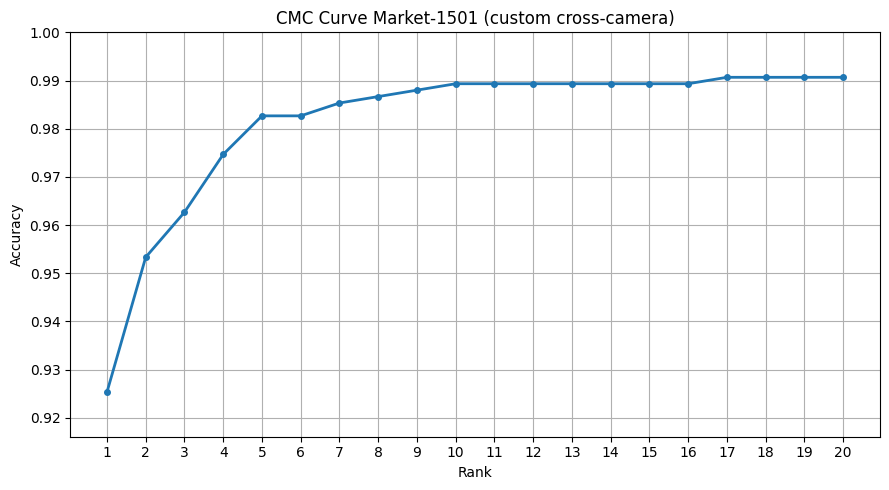

Rank-1=0.9253  Rank-5=0.9827  Rank-10=0.9893  Rank-20=0.9907  mAP=0.8455


In [9]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, MAX_RANK + 1), cmc, marker='o', linewidth=2, markersize=4)
plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.title('CMC Curve Market-1501 (custom cross-camera)')
plt.xticks(range(1, MAX_RANK + 1))
plt.ylim(cmc[0] * 0.99, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig('market1501_cmc_custom.png', dpi=150)
plt.show()

print(f'Rank-1={cmc[0]:.4f}  Rank-5={cmc[4]:.4f}  Rank-10={cmc[9]:.4f}  Rank-20={cmc[19]:.4f}  mAP={mAP:.4f}')

In [12]:
def aqe(q_embs, g_embs, k=7, alpha=3.0):
    sim = q_embs @ g_embs.T
    weights = np.clip(sim, 0, None) ** alpha
    top_k = np.argsort(-sim, axis=1)[:, :k]
    q_exp = q_embs.copy()
    for i in range(len(q_embs)):
        w = weights[i, top_k[i], np.newaxis]
        q_exp[i] = q_embs[i] + (w * g_embs[top_k[i]]).sum(0)
    norms = np.linalg.norm(q_exp, axis=1, keepdims=True)
    return q_exp / (norms + 1e-12)

In [ ]:
q_exp = aqe(q_embs, g_embs, k=7, alpha=3.0)
r1_aqe, m_aqe = evaluate(q_exp, q_pids, g_embs, g_pids)
print(f'AQE only:         Rank-1={r1_aqe:.4f}  mAP={m_aqe:.4f}')

for k1 in [10, 12, 14, 16]:
    for lam in [0.2, 0.25, 0.3, 0.35]:
        r1, m = evaluate_rerank(q_embs, q_pids, g_embs, g_pids,
                                k1=k1, k2=2, lambda_value=lam)
        print(f'k1={k1:2d} lam={lam:.2f}  Rank-1={r1:.4f}  mAP={m:.4f}')


AQE only:         Rank-1=0.8880  mAP=0.8459
k1=10 lam=0.20  Rank-1=0.9200  mAP=0.8968
k1=10 lam=0.25  Rank-1=0.9200  mAP=0.8966
k1=10 lam=0.30  Rank-1=0.9213  mAP=0.8958
k1=10 lam=0.35  Rank-1=0.9213  mAP=0.8943
k1=12 lam=0.20  Rank-1=0.9213  mAP=0.8920
k1=12 lam=0.25  Rank-1=0.9213  mAP=0.8922
k1=12 lam=0.30  Rank-1=0.9213  mAP=0.8912
k1=12 lam=0.35  Rank-1=0.9213  mAP=0.8902
k1=14 lam=0.20  Rank-1=0.9227  mAP=0.8898
k1=14 lam=0.25  Rank-1=0.9200  mAP=0.8888
k1=14 lam=0.30  Rank-1=0.9227  mAP=0.8886
k1=14 lam=0.35  Rank-1=0.9227  mAP=0.8877
k1=16 lam=0.20  Rank-1=0.9227  mAP=0.8874
k1=16 lam=0.25  Rank-1=0.9227  mAP=0.8869
k1=16 lam=0.30  Rank-1=0.9240  mAP=0.8866
k1=16 lam=0.35  Rank-1=0.9253  mAP=0.8857


In [13]:
import gc
import matplotlib.pyplot as plt
import numpy as np

model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))

SEQ_LENS = list(range(1, MAX_SEQ_LEN + 1))
rank1_by_len, mAP_by_len = [], []

for L in SEQ_LENS:
    gc.collect()
    torch.cuda.empty_cache()

    q_embs_L, q_pids_L, _ = encode_sequences(query_seqs,   model, test_transform, device,
                                              max_seq_len=L, flip_tta=False)
    g_embs_L, g_pids_L, _ = encode_sequences(gallery_seqs, model, test_transform, device,
                                              max_seq_len=L, flip_tta=False)
    r1_L, mAP_L = evaluate(q_embs_L, q_pids_L, g_embs_L, g_pids_L)
    rank1_by_len.append(r1_L)
    mAP_by_len.append(mAP_L)
    print(f'max_seq_len={L:2d}  Rank-1={r1_L:.4f}  mAP={mAP_L:.4f}')

best_L     = SEQ_LENS[int(np.argmax(rank1_by_len))]
best_L_mAP = SEQ_LENS[int(np.argmax(mAP_by_len))]
best_r1    = max(rank1_by_len)
best_mAP   = max(mAP_by_len)


Encoding: 100%|██████████| 190/190 [00:14<00:00, 13.06it/s]


max_seq_len= 1  Rank-1=0.8933  mAP=0.8012


Encoding: 100%|██████████| 190/190 [00:20<00:00,  9.05it/s]


max_seq_len= 2  Rank-1=0.9147  mAP=0.8368


Encoding: 100%|██████████| 190/190 [00:23<00:00,  8.21it/s]


...

max_seq_len= 6  Rank-1=0.9160  mAP=0.8399


Encoding: 100%|██████████| 190/190 [00:24<00:00,  7.63it/s]


max_seq_len= 7  Rank-1=0.9160  mAP=0.8400


Encoding: 100%|██████████| 190/190 [00:25<00:00,  7.51it/s]


max_seq_len= 8  Rank-1=0.9160  mAP=0.8400


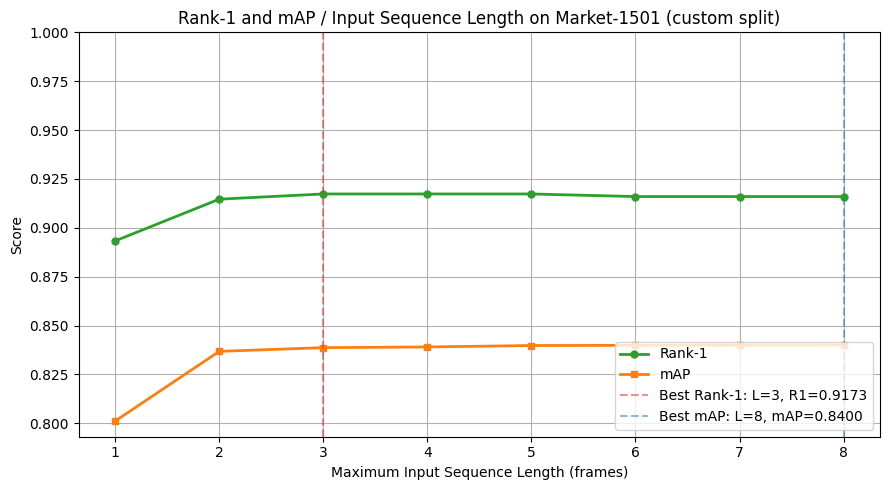

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(SEQ_LENS, rank1_by_len, marker='o', linewidth=2, markersize=5, color='tab:green', label='Rank-1')
plt.plot(SEQ_LENS, mAP_by_len,   marker='s', linewidth=2, markersize=5, color='tab:orange', label='mAP')
plt.axvline(best_L,     color='tab:red',  linestyle='--', alpha=0.5,
            label=f'Best Rank-1: L={best_L}, R1={best_r1:.4f}')
plt.axvline(best_L_mAP, color='tab:blue', linestyle='--', alpha=0.5,
            label=f'Best mAP: L={best_L_mAP}, mAP={best_mAP:.4f}')

plt.xlabel('Maximum Input Sequence Length (frames)')
plt.ylabel('Score')
plt.title('Rank-1 and mAP / Input Sequence Length on Market-1501 (Official)')
plt.xticks(SEQ_LENS)
plt.ylim(min(min(rank1_by_len), min(mAP_by_len)) * 0.99, 1)
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('market1501_rank1_map_vs_seqlen.png', dpi=150)
plt.show()


In [15]:
import gc
import matplotlib.pyplot as plt
import numpy as np


model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))

gc.collect()
torch.cuda.empty_cache()
g_embs_full, g_pids_full, _ = encode_sequences(gallery_seqs, model, test_transform, device,
                                                max_seq_len=MAX_SEQ_LEN, flip_tta=False)

QUERY_SEQ_LENS = list(range(1, MAX_SEQ_LEN + 1))
rank1_qonly, mAP_qonly = [], []

for L in QUERY_SEQ_LENS:
    gc.collect()
    torch.cuda.empty_cache()
    q_embs_L, q_pids_L, _ = encode_sequences(query_seqs, model, test_transform, device,
                                              max_seq_len=L, flip_tta=False)
    r1_L, mAP_L = evaluate(q_embs_L, q_pids_L, g_embs_full, g_pids_full)
    rank1_qonly.append(r1_L)
    mAP_qonly.append(mAP_L)
    print(f'query max_seq_len={L:2d}  Rank-1={r1_L:.4f}  mAP={mAP_L:.4f}')

best_L     = QUERY_SEQ_LENS[int(np.argmax(rank1_qonly))]
best_L_mAP = QUERY_SEQ_LENS[int(np.argmax(mAP_qonly))]
best_r1    = max(rank1_qonly)
best_mAP   = max(mAP_qonly)


Encoding: 100%|██████████| 24/24 [00:01<00:00, 12.79it/s]


query max_seq_len= 1  Rank-1=0.9053  mAP=0.8240


Encoding: 100%|██████████| 24/24 [00:02<00:00,  8.47it/s]


query max_seq_len= 2  Rank-1=0.9147  mAP=0.8407


Encoding: 100%|██████████| 24/24 [00:03<00:00,  7.79it/s]


...

query max_seq_len= 6  Rank-1=0.9160  mAP=0.8400


Encoding: 100%|██████████| 24/24 [00:03<00:00,  7.59it/s]


query max_seq_len= 7  Rank-1=0.9160  mAP=0.8400


Encoding: 100%|██████████| 24/24 [00:03<00:00,  7.45it/s]


query max_seq_len= 8  Rank-1=0.9160  mAP=0.8400


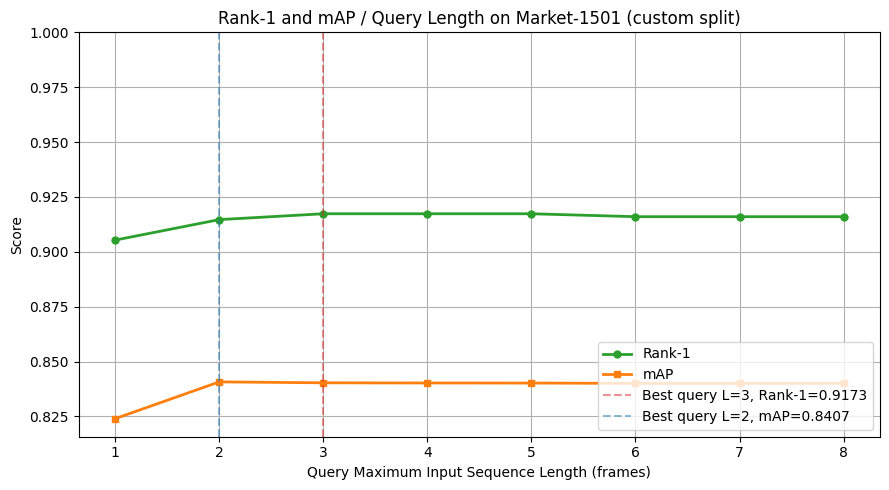

In [16]:
plt.figure(figsize=(9, 5))

plt.plot(QUERY_SEQ_LENS, rank1_qonly, marker='o', linewidth=2, markersize=5, color='tab:green', label='Rank-1')
plt.plot(QUERY_SEQ_LENS, mAP_qonly,   marker='s', linewidth=2, markersize=5, color='tab:orange', label='mAP')
plt.axvline(best_L,     color='tab:red',  linestyle='--', alpha=0.5,
            label=f'Best query L={best_L}, Rank-1={best_r1:.4f}')
plt.axvline(best_L_mAP, color='tab:blue', linestyle='--', alpha=0.5,
            label=f'Best query L={best_L_mAP}, mAP={best_mAP:.4f}')

plt.xlabel('Query Maximum Input Sequence Length (frames)')
plt.ylabel('Score')
plt.title('Rank-1 and mAP / Query Length on Market-1501 (custom split)')
plt.xticks(QUERY_SEQ_LENS)
plt.ylim(min(min(rank1_qonly), min(mAP_qonly)) * 0.99, 1)
plt.grid(True)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('market1501_rank1_map_vs_query_seqlen.png', dpi=150)
plt.show()


In [8]:

import gc
import matplotlib.pyplot as plt

model.load_state_dict(torch.load(BEST_CKPT, map_location=device, weights_only=True))
model.eval()
gc.collect()
torch.cuda.empty_cache()

q_embs_off, q_pids_off, q_cams_off = encode_sequences(
    query_seqs_official, model, test_transform, device, flip_tta=True)
g_embs_off, g_pids_off, g_cams_off = encode_sequences(
    gallery_seqs_official, model, test_transform, device,
    max_seq_len=MAX_SEQ_LEN, flip_tta=True)

print(f'Query  embeddings: {q_embs_off.shape}')
print(f'Gallery embeddings: {g_embs_off.shape}')
print(f'  unique gallery pids: {len(np.unique(g_pids_off))}  '
      f'(includes -1 and 0)')

sim         = cos_sim(q_embs_off, g_embs_off)
sorted_off  = np.argsort(-sim, axis=1)
MAX_RANK    = 20
rank1_off, mAP_off, cmc_official = _score_with_junk(
    sorted_off, q_pids_off, q_cams_off, g_pids_off, g_cams_off, max_rank=MAX_RANK)


Encoding: 100%|██████████| 369/369 [01:18<00:00,  4.71it/s]


Query  embeddings: (3368, 512)
Gallery embeddings: (11783, 512)
  unique gallery pids: 752  (includes -1 and 0)


Official Market-1501 evaluation (with flip TTA)
  queries scored : 3368
  Rank-1   : 0.9175
  Rank-5   : 0.9697
  Rank-10  : 0.9831
  Rank-20  : 0.9887
  mAP      : 0.8291


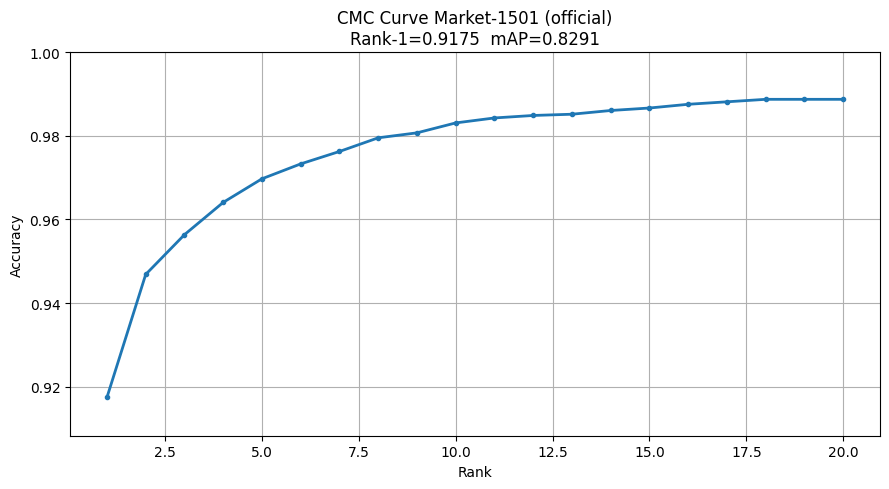

In [9]:
print('Official Market-1501 evaluation (with flip TTA)')
print(f'  queries scored : {len(q_pids_off)}')
print(f'  Rank-1   : {cmc_official[0]:.4f}')
print(f'  Rank-5   : {cmc_official[4]:.4f}')
print(f'  Rank-10  : {cmc_official[9]:.4f}')
print(f'  Rank-20  : {cmc_official[19]:.4f}')
print(f'  mAP      : {mAP_off:.4f}')

plt.figure(figsize=(9, 5))
plt.plot(range(1, MAX_RANK + 1), cmc_official, marker='o', linewidth=2, markersize=3)
plt.xlabel('Rank')
plt.ylabel('Accuracy')
plt.title(f'CMC Curve Market-1501 (official)\n'
          f'Rank-1={cmc_official[0]:.4f}  mAP={mAP_off:.4f}')
plt.ylim(cmc_official[0] * 0.99, 1)
plt.grid(True)
plt.tight_layout()
plt.savefig('market1501_cmc_official.png', dpi=150)
plt.show()


In [15]:

q_exp_off = aqe(q_embs_off, g_embs_off, k=7, alpha=3.0)
sim_aqe   = q_exp_off @ g_embs_off.T
sorted_aqe = np.argsort(-sim_aqe, axis=1)
r1_aqe, m_aqe, _ = _score_with_junk(sorted_aqe, q_pids_off, q_cams_off,
                                    g_pids_off, g_cams_off, max_rank=20)
print(f'AQE only:         Rank-1={r1_aqe:.4f}  mAP={m_aqe:.4f}')

for k1 in [10, 12, 14, 16]:
    for lam in [0.2, 0.25, 0.3, 0.35]:
        dist_rr     = re_ranking(q_embs_off, g_embs_off, k1=k1, k2=2, lambda_value=lam)
        sorted_rr   = np.argsort(dist_rr, axis=1)
        r1, m, _    = _score_with_junk(sorted_rr, q_pids_off, q_cams_off,
                                       g_pids_off, g_cams_off, max_rank=20)
        print(f'k1={k1:2d} lam={lam:.2f}  Rank-1={r1:.4f}  mAP={m:.4f}')


AQE only:         Rank-1=0.9148  mAP=0.8526
k1=10 lam=0.20  Rank-1=0.9326  mAP=0.8814
k1=10 lam=0.25  Rank-1=0.9335  mAP=0.8795
k1=10 lam=0.30  Rank-1=0.9338  mAP=0.8775
k1=10 lam=0.35  Rank-1=0.9329  mAP=0.8753
k1=12 lam=0.20  Rank-1=0.9332  mAP=0.8890
k1=12 lam=0.25  Rank-1=0.9344  mAP=0.8866
k1=12 lam=0.30  Rank-1=0.9335  mAP=0.8840
k1=12 lam=0.35  Rank-1=0.9329  mAP=0.8818
k1=14 lam=0.20  Rank-1=0.9302  mAP=0.8889
k1=14 lam=0.25  Rank-1=0.9305  mAP=0.8869
k1=14 lam=0.30  Rank-1=0.9311  mAP=0.8847
k1=14 lam=0.35  Rank-1=0.9320  mAP=0.8826
k1=16 lam=0.20  Rank-1=0.9284  mAP=0.8901
k1=16 lam=0.25  Rank-1=0.9287  mAP=0.8883
k1=16 lam=0.30  Rank-1=0.9290  mAP=0.8861
k1=16 lam=0.35  Rank-1=0.9296  mAP=0.8838


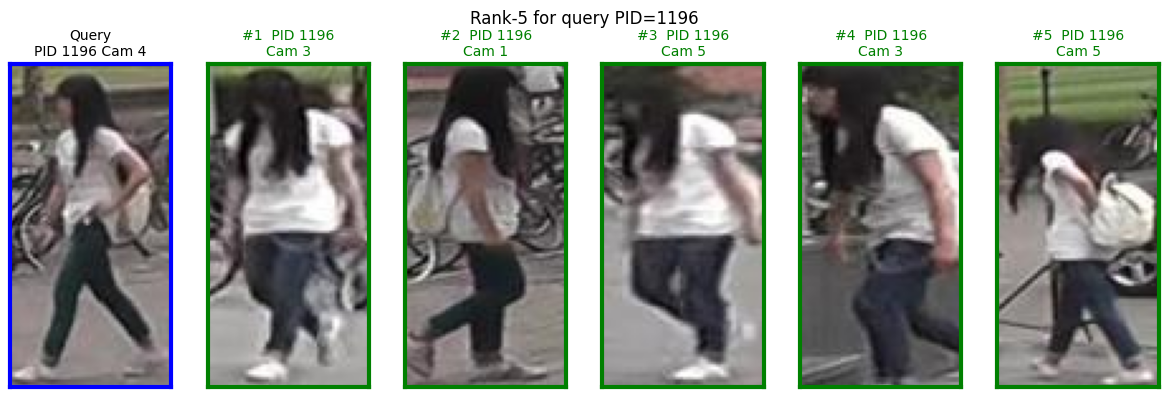

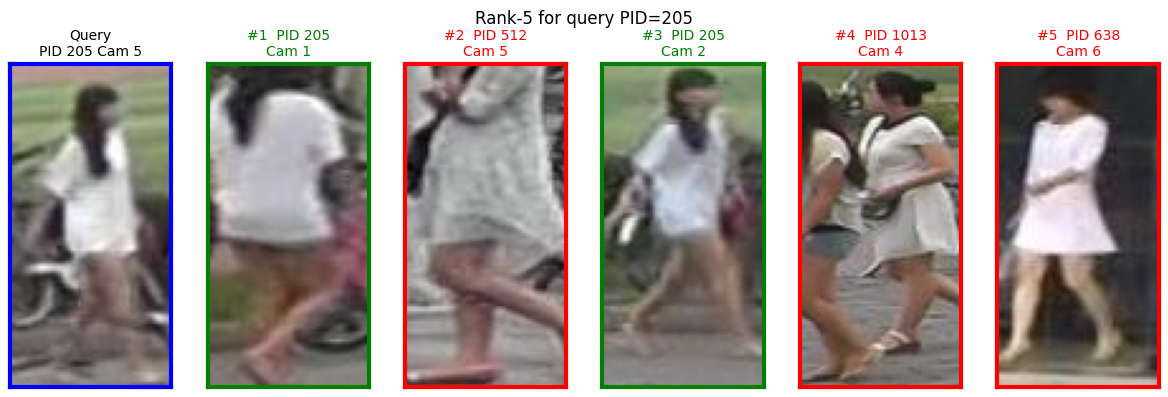

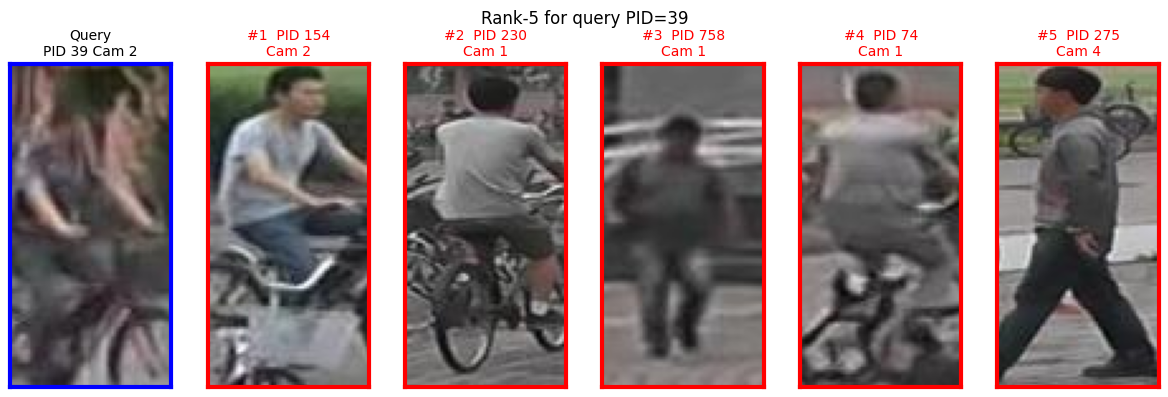

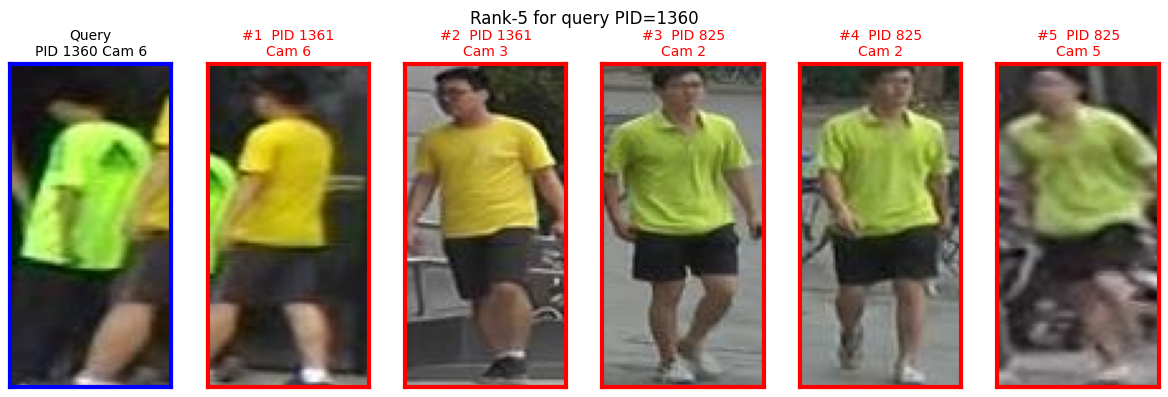

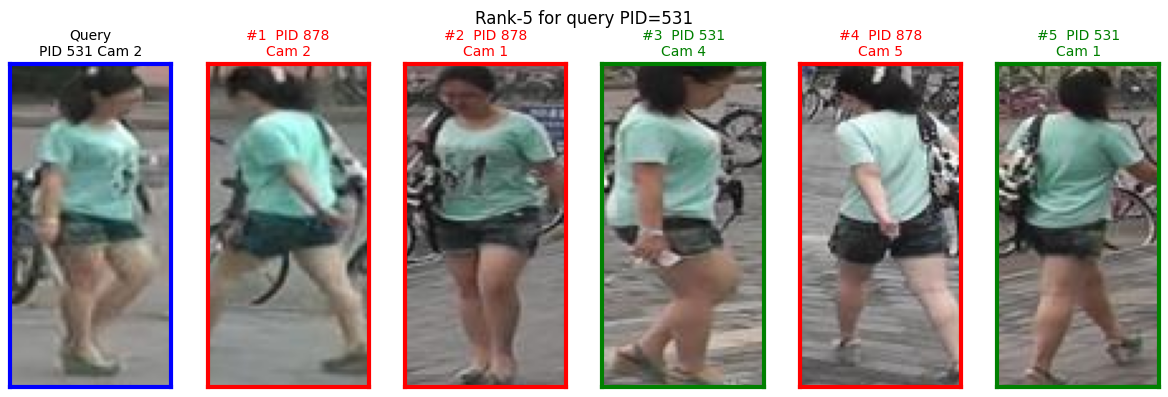

In [20]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def _seq_len(seq, cap):
    s = seq if cap is None else seq[:cap]
    return len(s)

q_seqs_sorted = sorted(query_seqs_official,   key=lambda s: _seq_len(s, None))
g_seqs_sorted = sorted(gallery_seqs_official, key=lambda s: _seq_len(s, MAX_SEQ_LEN))

assert all(s[0].person_id == p for s, p in zip(q_seqs_sorted, q_pids_off))
assert all(s[0].person_id == p for s, p in zip(g_seqs_sorted, g_pids_off))

N_QUERIES = 5
TOP_K     = 5

random.seed(42)
candidate_qs = [
    i for i in range(len(q_pids_off))
    if ((g_pids_off == q_pids_off[i]) & (g_cams_off != q_cams_off[i])).any()
]
sample_idx = random.sample(candidate_qs, min(N_QUERIES, len(candidate_qs)))

for qi in sample_idx:
    q_pid = int(q_pids_off[qi])
    q_cam = int(q_cams_off[qi])
    q_seq = q_seqs_sorted[qi]

    ranked = sorted_off[qi]
    g_pid_r = g_pids_off[ranked]
    g_cam_r = g_cams_off[ranked]
    junk = (g_pid_r == 0) | (g_pid_r == -1) | \
           ((g_pid_r == q_pid) & (g_cam_r == q_cam))
    ranked_clean = ranked[~junk][:TOP_K]

    fig, axes = plt.subplots(1, TOP_K + 1, figsize=(2 * (TOP_K + 1), 4))

    img = Image.open(q_seq[0].image_path).convert('RGB')
    axes[0].imshow(img)
    axes[0].set_title(f'Query\nPID {q_pid} Cam {q_cam}', fontsize=10)
    axes[0].set_xticks([]); axes[0].set_yticks([])
    for s in axes[0].spines.values():
        s.set_edgecolor('blue'); s.set_linewidth(3)

    for k, gi in enumerate(ranked_clean):
        g_pid_k = int(g_pids_off[gi])
        g_cam_k = int(g_cams_off[gi])
        g_seq   = g_seqs_sorted[gi]
        img     = Image.open(g_seq[0].image_path).convert('RGB')
        ax      = axes[k + 1]
        ax.imshow(img)
        correct = (g_pid_k == q_pid)
        color   = 'green' if correct else 'red'
        ax.set_title(f'#{k+1}  PID {g_pid_k}\nCam {g_cam_k}', fontsize=10, color=color)
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_edgecolor(color); s.set_linewidth(3)

    plt.suptitle(f'Rank-{TOP_K} for query PID={q_pid}', fontsize=12)
    plt.tight_layout()
    plt.show()
